In [1]:
!apt-get -qq install fonts-nanum > /dev/null
import matplotlib.font_manager as fm
fm.fontManager.addfont('/usr/share/fonts/truetype/nanum/NanumGothic.ttf')

import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import fisher_exact

plt.rcParams['font.family'] = 'NanumGothic'
plt.rcParams['axes.unicode_minus'] = False

# ---------- 데이터 로드 & 그룹 정의 (D-5 항진균크림, OTC 확정 케이스) ----------
df = pd.read_csv("FDA_adverse_events_final.csv", low_memory=False)
d = df[df["WHO_ATC"] == "D"]

mask = (
    d["suspect_drug"].str.contains("CLOTRIMAZOLE|MICONAZOLE|LOTRIMIN|NIZORAL", case=False, na=False)
    | d["brand_name"].str.contains("CLOTRIMAZOLE|MICONAZOLE|LOTRIMIN|NIZORAL", case=False, na=False)
)
sub = df.loc[d[mask].index].copy()
otc = sub[~sub["suspect_drug"].str.contains("MICONAZOLE", case=False, na=False)].copy()  # Oravig 4건 제외
rest = df.drop(otc.index)
N = len(otc)



전체 N=18
연령대: {'Adult(19-40)': 0, 'Middle-Aged(41-65)': 1, 'Senior(66-80)': 3, 'Elderly(81+)': 1, 'Unknown': 13}
성별: {'Female': 6, 'Male': 4, 'Unknown': 8}
심각(Serious): {'Yes': 4, 'No': 14}
세부 플래그: {'is_fatal': np.int64(0), 'is_hospitalized': np.int64(2), 'is_life_threat': np.int64(1), 'is_disabling': np.int64(0)}


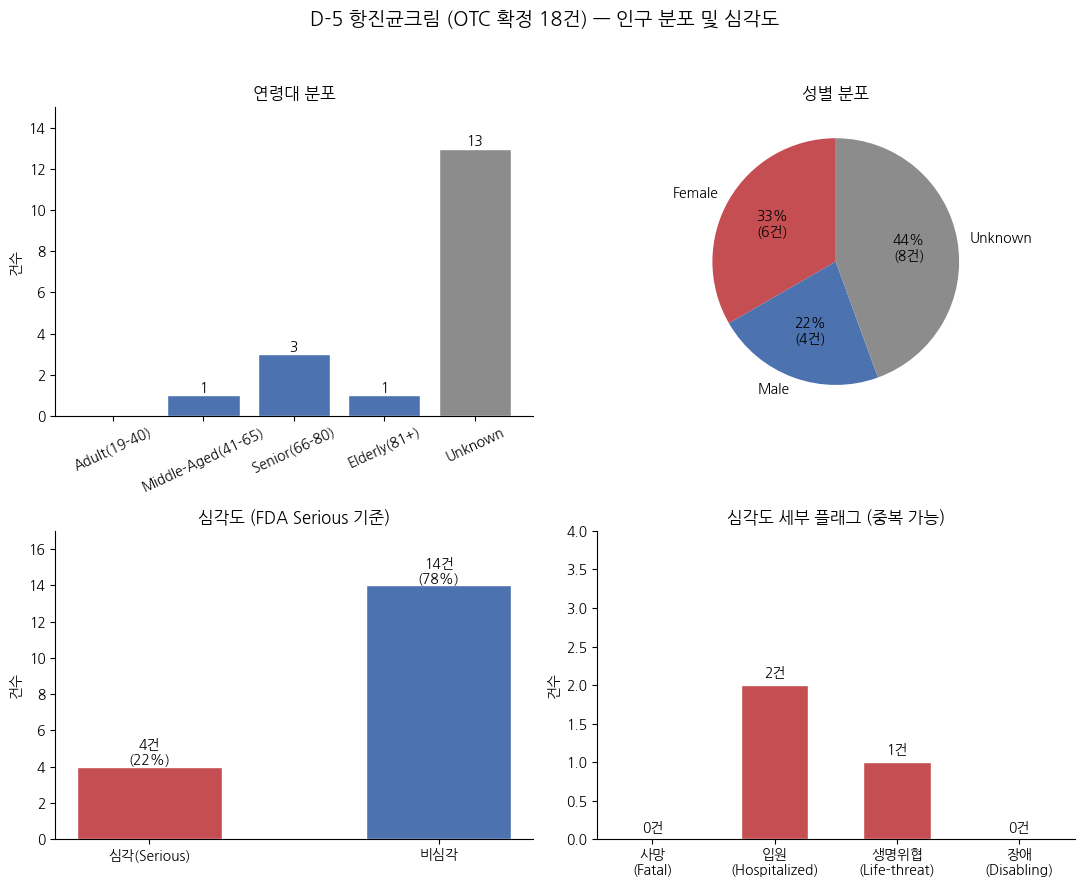

In [2]:
# ---------- 색상 컨벤션 ----------
COLOR_MAIN = "#C44E52"    # 그룹 강조색 (red)
COLOR_BASE = "#4C72B0"    # 보조색 (blue)
COLOR_NEUTRAL = "#8C8C8C"

# ==================================================================
# Figure: 2x2 서브플롯
# ==================================================================
fig, axes = plt.subplots(2, 2, figsize=(11, 9))
fig.suptitle(f"D-5 항진균크림 (OTC 확정 {N}건) — 인구 분포 및 심각도",
             fontsize=14, fontweight="bold", y=0.98)

# ---------- (1) 연령대 분포 ----------
ax = axes[0, 0]
age_order = ["Adult(19-40)", "Middle-Aged(41-65)", "Senior(66-80)", "Elderly(81+)", "Unknown"]
age_counts = otc["age_group"].value_counts().reindex(age_order, fill_value=0)
colors_age = [COLOR_NEUTRAL if idx == "Unknown" else COLOR_BASE for idx in age_counts.index]
bars = ax.bar(age_counts.index, age_counts.values, color=colors_age, edgecolor="white")
for b, v in zip(bars, age_counts.values):
    if v > 0:
        ax.text(b.get_x() + b.get_width()/2, v + 0.15, str(v), ha="center", fontsize=10, fontweight="bold")
ax.set_title("연령대 분포", fontsize=12, fontweight="bold")
ax.set_ylabel("건수")
ax.tick_params(axis="x", rotation=25)
ax.spines[["top", "right"]].set_visible(False)
ax.set_ylim(0, age_counts.max() + 2)

# ---------- (2) 성별 분포 ----------
ax = axes[0, 1]
sex_order = ["Female", "Male", "Unknown"]
sex_counts = otc["patient_sex"].value_counts().reindex(sex_order, fill_value=0)
colors_sex = ["#C44E52", "#4C72B0", "#8C8C8C"]
wedges, texts, autotexts = ax.pie(
    sex_counts.values, labels=sex_counts.index, colors=colors_sex,
    autopct=lambda p: f"{p:.0f}%\n({int(round(p*N/100))}건)" if p > 0 else "",
    startangle=90, textprops={"fontsize": 10}
)
ax.set_title("성별 분포", fontsize=12, fontweight="bold")

# ---------- (3) 심각도 (serious yes/no) ----------
ax = axes[1, 0]
serious_counts = otc["serious"].value_counts().reindex(["Yes", "No"], fill_value=0)
colors_serious = [COLOR_MAIN, COLOR_BASE]
bars = ax.bar(["심각(Serious)", "비심각"], serious_counts.values, color=colors_serious, edgecolor="white", width=0.5)
for b, v in zip(bars, serious_counts.values):
    pct = v / N * 100
    ax.text(b.get_x() + b.get_width()/2, v + 0.15, f"{v}건\n({pct:.0f}%)", ha="center", fontsize=10, fontweight="bold")
ax.set_title("심각도 (FDA Serious 기준)", fontsize=12, fontweight="bold")
ax.set_ylabel("건수")
ax.spines[["top", "right"]].set_visible(False)
ax.set_ylim(0, serious_counts.max() + 3)

# ---------- (4) 심각도 세부 플래그 ----------
ax = axes[1, 1]
flag_labels = ["사망\n(Fatal)", "입원\n(Hospitalized)", "생명위협\n(Life-threat)", "장애\n(Disabling)"]
flag_cols = ["is_fatal", "is_hospitalized", "is_life_threat", "is_disabling"]
flag_counts = [otc[c].sum() for c in flag_cols]
bars = ax.bar(flag_labels, flag_counts, color=COLOR_MAIN, edgecolor="white", width=0.55)
for b, v in zip(bars, flag_counts):
    ax.text(b.get_x() + b.get_width()/2, v + 0.1, f"{v}건", ha="center", fontsize=10, fontweight="bold")
ax.set_title("심각도 세부 플래그 (중복 가능)", fontsize=12, fontweight="bold")
ax.set_ylabel("건수")
ax.spines[["top", "right"]].set_visible(False)
ax.set_ylim(0, max(flag_counts) + 2)

plt.tight_layout(rect=[0, 0, 1, 0.95])

# ---------- 콘솔 요약 출력 ----------
print(f"\n전체 N={N}")
print("연령대:", age_counts.to_dict())
print("성별:", sex_counts.to_dict())
print("심각(Serious):", serious_counts.to_dict())
print("세부 플래그:", dict(zip(flag_cols, flag_counts)))


전체 OTC 확정 건수: 18
오적응증 사용 의심: 4 (22.2%)
오적응증 중 효과부족/품질 신고: 4/4 (100%)


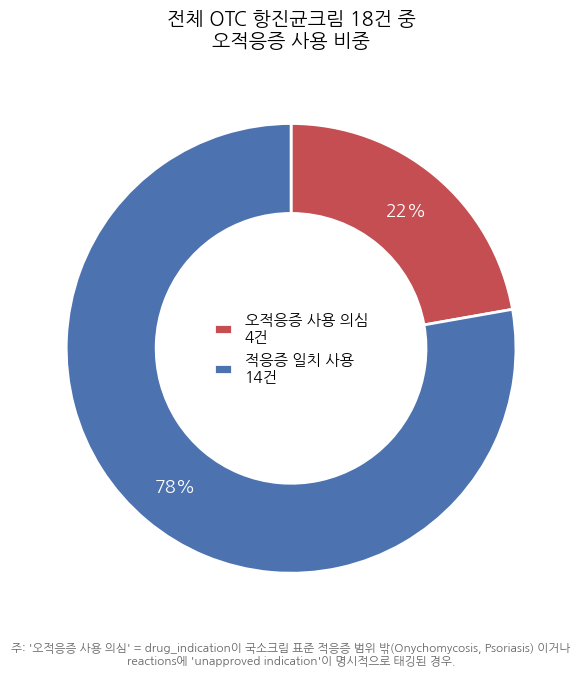

In [3]:
# ---------- 색상 컨벤션 ----------
COLOR_SIGNAL = "#C44E52"   # 오적응증/신호 (red)
COLOR_BASE = "#4C72B0"     # 일치 사용/베이스라인 (blue)

N_TOTAL = N

MISMATCH_INDICATIONS = ["Onychomycosis", "Psoriasis"]
otc["indication_mismatch"] = otc["drug_indication"].isin(MISMATCH_INDICATIONS)
otc["explicit_unapproved_flag"] = otc["reactions"].str.contains("unapproved indication", case=False, na=False)
otc["misuse_suspected"] = otc["indication_mismatch"] | otc["explicit_unapproved_flag"]
otc["ineffective_reported"] = otc["reactions"].str.contains("ineffective|quality issue", case=False, na=False)

N_MISUSE = int(otc["misuse_suspected"].sum())
N_MATCH = N_TOTAL - N_MISUSE
N_MISUSE_INEFFECTIVE = int((otc["misuse_suspected"] & otc["ineffective_reported"]).sum())

print(f"전체 OTC 확정 건수: {N_TOTAL}")
print(f"오적응증 사용 의심: {N_MISUSE} ({N_MISUSE/N_TOTAL*100:.1f}%)")
print(f"오적응증 중 효과부족/품질 신고: {N_MISUSE_INEFFECTIVE}/{N_MISUSE} ({N_MISUSE_INEFFECTIVE/N_MISUSE*100:.0f}%)")

# ==================================================================
# Figure: 도넛 차트 단일 패널
# ==================================================================
fig, ax = plt.subplots(figsize=(6.5, 6.5))

sizes = [N_MISUSE, N_MATCH]
labels = [f"오적응증 사용 의심\n{N_MISUSE}건", f"적응증 일치 사용\n{N_MATCH}건"]
colors = [COLOR_SIGNAL, COLOR_BASE]

wedges, texts, autotexts = ax.pie(
    sizes, colors=colors, startangle=90, counterclock=False,
    wedgeprops=dict(width=0.4, edgecolor="white", linewidth=2),
    autopct=lambda p: f"{p:.0f}%", pctdistance=0.8,
    textprops={"fontsize": 13, "fontweight": "bold", "color": "white"}
)
ax.legend(wedges, labels, loc="center", bbox_to_anchor=(0.5, 0.5),
          frameon=False, fontsize=11, handlelength=1.2)
ax.set_title(f"전체 OTC 항진균크림 {N_TOTAL}건 중\n오적응증 사용 비중",
             fontsize=14, fontweight="bold", pad=15)

fig.text(0.5, -0.03,
         "주: '오적응증 사용 의심' = drug_indication이 국소크림 표준 적응증 범위 밖(Onychomycosis, Psoriasis) 이거나\n"
         "reactions에 'unapproved indication'이 명시적으로 태깅된 경우.",
         ha="center", fontsize=8.5, color="#666666")

plt.tight_layout()


전체 OTC 확정 건수: 18
  지켜봐도 됨: 2건 (11%)
  상담 필요: 9건 (50%)
  즉시 병원: 7건 (39%)


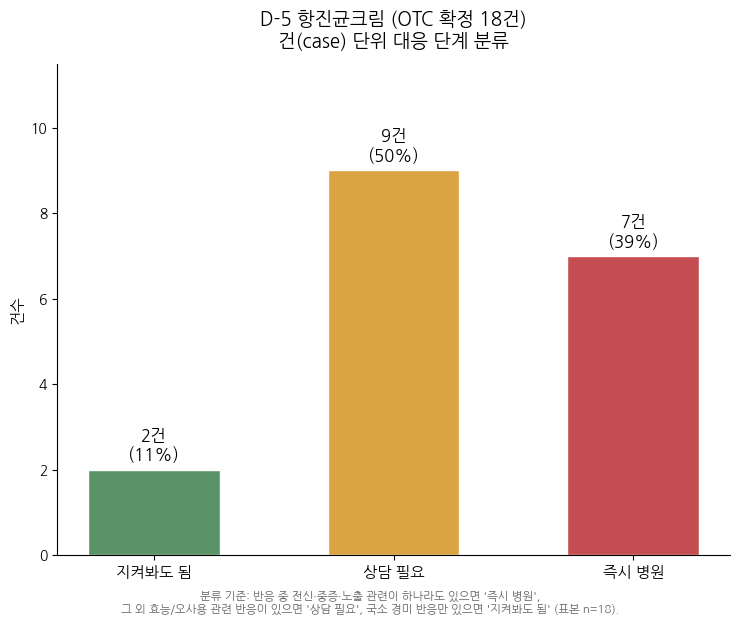

In [4]:
# ---------- 신호등 색상 ----------
COLOR_GREEN = "#5A9367"
COLOR_YELLOW = "#D9A441"
COLOR_RED = "#C44E52"

# ---------- 반응 -> 단계 매핑 (개별 반응 기준, 케이스 분류에 사용) ----------
GREEN_SET = {
    "Application site discomfort", "Application site pain", "Application site pruritus",
    "Erythema", "Rash", "Pruritus genital", "Genital burning sensation",
    "Vulvovaginal burning sensation", "Skin disorder", "Tinea pedis", "Alopecia",
}
YELLOW_SET = {
    "Drug ineffective", "Drug ineffective for unapproved indication",
    "Product use in unapproved indication", "Product quality issue",
    "Condition aggravated", "Product use issue", "Product substitution issue",
    "Quality of life decreased", "Psoriasis", "Product dose omission issue",
    "Product packaging difficult to open", "Intentional underdose",
}
# 그 외 전부 RED(전신/중증/노출)로 취급

def classify_case(reactions_str):
    if pd.isna(reactions_str):
        return "분류불가"
    items = {x.strip() for x in reactions_str.split(";")}
    if items - GREEN_SET - YELLOW_SET:       # RED 반응이 하나라도 있으면 즉시 병원
        return "즉시 병원"
    elif items & YELLOW_SET:                  # YELLOW 반응이 있으면 상담 필요
        return "상담 필요"
    elif items & GREEN_SET:                   # GREEN 반응만 있으면 지켜봐도 됨
        return "지켜봐도 됨"
    else:
        return "분류불가"

otc["case_tier"] = otc["reactions"].apply(classify_case)

tier_order = ["지켜봐도 됨", "상담 필요", "즉시 병원"]
tier_colors = {"지켜봐도 됨": COLOR_GREEN, "상담 필요": COLOR_YELLOW, "즉시 병원": COLOR_RED}
case_counts = otc["case_tier"].value_counts().reindex(tier_order, fill_value=0)

print(f"전체 OTC 확정 건수: {N}")
for tier in tier_order:
    print(f"  {tier}: {case_counts[tier]}건 ({case_counts[tier]/N*100:.0f}%)")

# ==================================================================
# Figure: 케이스 단위 비교 막대
# ==================================================================
fig, ax = plt.subplots(figsize=(7.5, 6))

bars = ax.bar(tier_order, case_counts.values,
              color=[tier_colors[t] for t in tier_order], edgecolor="white", width=0.55)

for b, tier in zip(bars, tier_order):
    v = case_counts[tier]
    pct = v / N * 100
    ax.text(b.get_x() + b.get_width()/2, v + 0.15, f"{v}건\n({pct:.0f}%)",
            ha="center", va="bottom", fontsize=12, fontweight="bold")

ax.set_ylabel("건수", fontsize=11)
ax.set_ylim(0, case_counts.max() + 2.5)
ax.set_title(f"D-5 항진균크림 (OTC 확정 {N}건)\n건(case) 단위 대응 단계 분류",
             fontsize=13.5, fontweight="bold", pad=12)
ax.spines[["top", "right"]].set_visible(False)
ax.tick_params(axis="x", labelsize=11)

fig.text(0.5, -0.03,
         "분류 기준: 반응 중 전신·중증·노출 관련이 하나라도 있으면 '즉시 병원',\n"
         "그 외 효능/오사용 관련 반응이 있으면 '상담 필요', 국소 경미 반응만 있으면 '지켜봐도 됨' (표본 n=18).",
         ha="center", fontsize=8.3, color="#666666")

plt.tight_layout()



N_sub=18, N_rest=18255
Serious: 22.2% vs 85.6%
Polypharmacy: 22.2% vs 59.0%
                            reaction  a    c       PRR        p
                    Drug ineffective  5 1016  4.990978 0.002508
Product use in unapproved indication  2  243  8.347051 0.023783
                            Erythema  2   92 22.047101 0.003797


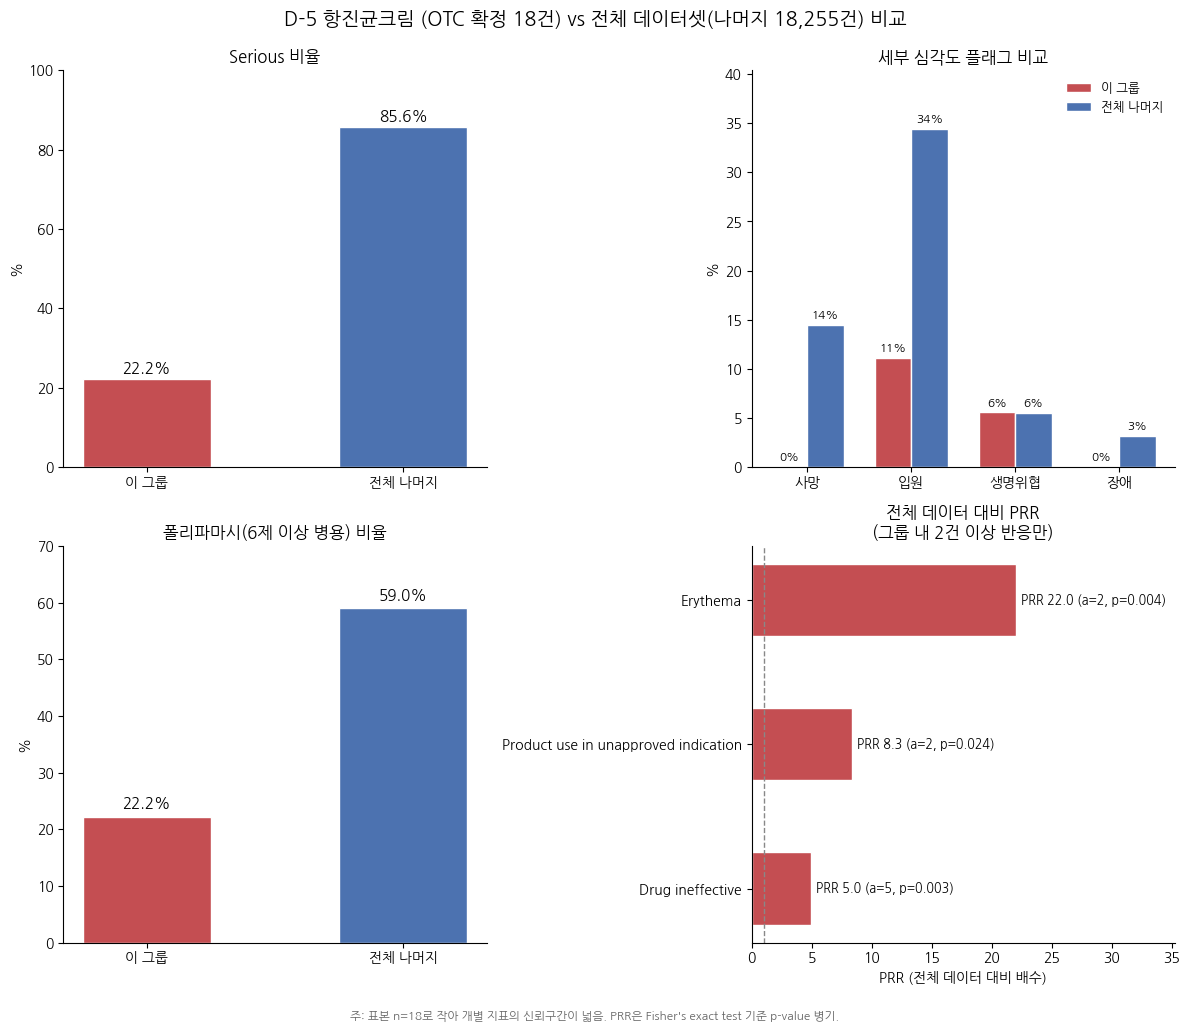

In [5]:
"""
D-5 (항진균크림) OTC 확정 18건 vs 전체 데이터셋(나머지) 비교 시각화
FAERS 소비자 드러그 세이프티 포트폴리오 프로젝트

컨벤션: 빨강(#C44E52) = 이 그룹, 파랑(#4C72B0) = 전체 나머지(베이스라인)
"""

# ---------- 색상 컨벤션 ----------
COLOR_GROUP = "#C44E52"   # 이 그룹 (red)
COLOR_BASE = "#4C72B0"    # 전체 나머지 (blue)

N_sub, N_rest = N, len(rest)

# ==================================================================
# Figure: 2x2
# ==================================================================
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
fig.suptitle(f"D-5 항진균크림 (OTC 확정 {N_sub}건) vs 전체 데이터셋(나머지 {N_rest:,}건) 비교",
             fontsize=14, fontweight="bold", y=0.99)

# ---------- (1) Serious 비율 ----------
ax = axes[0, 0]
sub_serious = (otc["serious"] == "Yes").mean() * 100
rest_serious = (rest["serious"] == "Yes").mean() * 100
bars = ax.bar(["이 그룹", "전체 나머지"], [sub_serious, rest_serious],
              color=[COLOR_GROUP, COLOR_BASE], edgecolor="white", width=0.5)
for b, v in zip(bars, [sub_serious, rest_serious]):
    ax.text(b.get_x() + b.get_width()/2, v + 1.5, f"{v:.1f}%", ha="center", fontsize=11, fontweight="bold")
ax.set_title("Serious 비율", fontsize=12, fontweight="bold")
ax.set_ylabel("%")
ax.set_ylim(0, 100)
ax.spines[["top", "right"]].set_visible(False)

# ---------- (2) 세부 심각도 플래그 비교 (그룹형 막대) ----------
ax = axes[0, 1]
flag_cols = ["is_fatal", "is_hospitalized", "is_life_threat", "is_disabling"]
flag_labels = ["사망", "입원", "생명위협", "장애"]
sub_vals = [otc[c].mean() * 100 for c in flag_cols]
rest_vals = [rest[c].mean() * 100 for c in flag_cols]

x = np.arange(len(flag_labels))
width = 0.35
ax.bar(x - width/2, sub_vals, width, color=COLOR_GROUP, label="이 그룹", edgecolor="white")
ax.bar(x + width/2, rest_vals, width, color=COLOR_BASE, label="전체 나머지", edgecolor="white")
for i, (sv, rv) in enumerate(zip(sub_vals, rest_vals)):
    ax.text(i - width/2, sv + 0.6, f"{sv:.0f}%", ha="center", fontsize=8.5)
    ax.text(i + width/2, rv + 0.6, f"{rv:.0f}%", ha="center", fontsize=8.5)
ax.set_xticks(x)
ax.set_xticklabels(flag_labels)
ax.set_ylabel("%")
ax.set_title("세부 심각도 플래그 비교", fontsize=12, fontweight="bold")
ax.legend(frameon=False, fontsize=9)
ax.spines[["top", "right"]].set_visible(False)
ax.set_ylim(0, max(rest_vals) + 6)

# ---------- (3) 폴리파마시 비율 비교 ----------
ax = axes[1, 0]
sub_poly = (otc["drug_count_category"] == "Polypharmacy(6+)").mean() * 100
rest_poly = (rest["drug_count_category"] == "Polypharmacy(6+)").mean() * 100
bars = ax.bar(["이 그룹", "전체 나머지"], [sub_poly, rest_poly],
              color=[COLOR_GROUP, COLOR_BASE], edgecolor="white", width=0.5)
for b, v in zip(bars, [sub_poly, rest_poly]):
    ax.text(b.get_x() + b.get_width()/2, v + 1.5, f"{v:.1f}%", ha="center", fontsize=11, fontweight="bold")
ax.set_title("폴리파마시(6제 이상 병용) 비율", fontsize=12, fontweight="bold")
ax.set_ylabel("%")
ax.set_ylim(0, 70)
ax.spines[["top", "right"]].set_visible(False)

# ---------- (4) PRR (그룹 내 2건 이상 반응) ----------
ax = axes[1, 1]

def explode(frame):
    return frame["reactions"].dropna().str.split(";").apply(lambda l: [x.strip() for x in l]).explode()

sub_r = explode(otc).value_counts()
rest_r = explode(rest).value_counts()

prr_rows = []
for reaction, a in sub_r.items():
    if a < 2:
        continue
    c = rest_r.get(reaction, 0)
    b_ = N_sub - a
    dd = N_rest - c
    prr = (a / N_sub) / (c / N_rest) if c > 0 else np.inf
    _, p = fisher_exact([[a, b_], [c, dd]])
    prr_rows.append((reaction, a, c, prr, p))

prr_df = pd.DataFrame(prr_rows, columns=["reaction", "a", "c", "PRR", "p"]).sort_values("PRR", ascending=True)

bars = ax.barh(prr_df["reaction"], prr_df["PRR"], color=COLOR_GROUP, edgecolor="white", height=0.5)
for bar, a, p in zip(bars, prr_df["a"], prr_df["p"]):
    ax.text(bar.get_width() + 0.4, bar.get_y() + bar.get_height()/2,
            f"PRR {bar.get_width():.1f} (a={a}, p={p:.3f})", va="center", fontsize=9)
ax.axvline(1, color="#888888", linestyle="--", linewidth=1)
ax.set_title("전체 데이터 대비 PRR\n(그룹 내 2건 이상 반응만)", fontsize=12, fontweight="bold")
ax.set_xlabel("PRR (전체 데이터 대비 배수)")
ax.set_xlim(0, prr_df["PRR"].max() * 1.6)
ax.spines[["top", "right"]].set_visible(False)

fig.text(0.5, -0.02,
         "주: 표본 n=18로 작아 개별 지표의 신뢰구간이 넓음. PRR은 Fisher's exact test 기준 p-value 병기.",
         ha="center", fontsize=8.5, color="#666666")

plt.tight_layout()
print(f"\nN_sub={N_sub}, N_rest={N_rest}")
print(f"Serious: {sub_serious:.1f}% vs {rest_serious:.1f}%")
print(f"Polypharmacy: {sub_poly:.1f}% vs {rest_poly:.1f}%")
print(prr_df.to_string(index=False))
